In [ ]:
# STEP 1: Install & authenticate Kaggle
!pip install -q kaggle

# Upload your Kaggle API key (kaggle.json)
from google.colab import files
files.upload()  # Upload the kaggle.json file

# Create kaggle folder and move the key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# STEP 2: Download the Animals-10 dataset
!kaggle datasets download -d alessiocorrado99/animals10

# Unzip the dataset
!unzip -q animals10.zip -d animals10


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
animals10.zip: Skipping, found more recently modified local copy (use --force to force download)
replace animals10/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace animals10/raw-img/cane/OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace animals10/raw-img/cane/OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace animals10/raw-img/cane/OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel",
}

In [ ]:
directory=r"/content/animals10/raw-img"
batch_size = 32
img_size = 224





In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [ ]:
datagen = ImageDataGenerator(
    rescale=1/255.,
    horizontal_flip=True,
    validation_split=0.1
)


train_generator = datagen.flow_from_directory(
    directory,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True,
    subset='training',
    class_mode='categorical'
)


validation_generator = datagen.flow_from_directory( directory,
  target_size=(img_size, img_size),
   batch_size=batch_size,
    shuffle=False,
   subset='validation',
   class_mode='categorical'
)

Found 23565 images belonging to 10 classes.
Found 2614 images belonging to 10 classes.


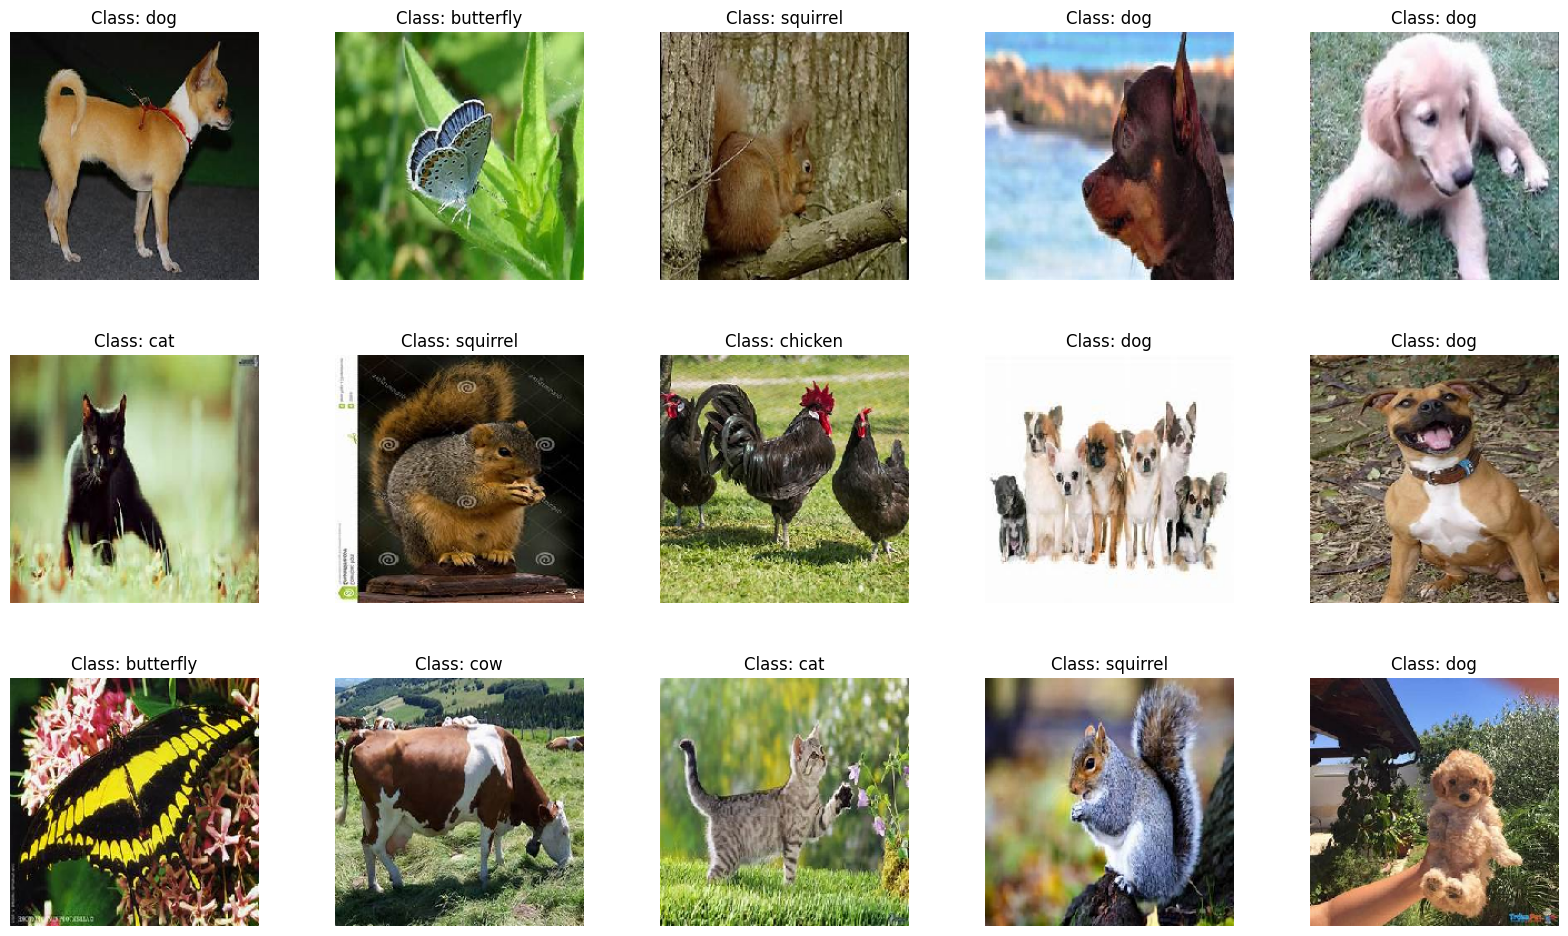

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
labels = [k for k in train_generator.class_indices]
translated_labels = [translate[label] for label in labels]
sample_generate = train_generator.__next__()
images = sample_generate[0]
titles = sample_generate[1]
plt.figure(figsize=(20, 20))


for i in range(15):
    plt.subplot(5, 5, i+1)
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.imshow(images[i])
    plt.title(f'Class: {translated_labels[np.argmax(titles[i], axis=0)]}')
    plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Input, Dropout,
                                     concatenate)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import os
import time


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Input, concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
def inception_module_v3(x, f1, f3r, f3, f3dbl_r, f3dbl_1, f3dbl_2, pool_proj):
    conv1 = Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    conv1 = BatchNormalization()(conv1)

    conv3 = Conv2D(f3r, (1, 1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f3, (3, 3), padding='same', activation='relu')(conv3)
    conv3 = BatchNormalization()(conv3)

    conv3dbl = Conv2D(f3dbl_r, (1, 1), padding='same', activation='relu')(x)
    conv3dbl = Conv2D(f3dbl_1, (3, 3), padding='same', activation='relu')(conv3dbl)
    conv3dbl = Conv2D(f3dbl_2, (3, 3), padding='same', activation='relu')(conv3dbl)
    conv3dbl = BatchNormalization()(conv3dbl)

    pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(pool)
    pool = BatchNormalization()(pool)

    output = concatenate([conv1, conv3, conv3dbl, pool], axis=3)
    output = Dropout(0.3)(output)
    return output

def build_inception_model_v3(input_shape=(224, 224, 3), num_classes=10):
    input_layer = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='valid', activation='relu')(input_layer)
    x = Conv2D(32, (3, 3), padding='valid', activation='relu')(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = Conv2D(80, (1, 1), padding='valid', activation='relu')(x)
    x = Conv2D(192, (3, 3), padding='valid', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = inception_module_v3(x, 64, 48, 64, 64, 96, 96, 32)
    x = inception_module_v3(x, 64, 48, 64, 64, 96, 96, 64)
    x = inception_module_v3(x, 64, 48, 64, 64, 96, 96, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module_v3(x, 128, 64, 96, 64, 96, 96, 64)
    x = inception_module_v3(x, 128, 64, 96, 64, 96, 96, 64)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=x)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
model = build_inception_model_v3()
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

# Phase 1: Train only top layers
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=callbacks
)

# Phase 2: Unfreeze and fine-tune
model.layers[0].trainable = True  # Unfreeze base_model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # Smaller LR
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=callbacks
)

# Final evaluation
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=0)
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


737/737 ━━━━━━━━━━━━━━━━━━━━ 156s 145ms/step - accuracy: 0.3067 - loss: 1.9868 - val_accuracy: 0.2112 - val_loss: 4.2319 - learning_rate: 0.0010
Epoch 2/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.5407 - loss: 1.3311 - val_accuracy: 0.3313 - val_loss: 2.5655 - learning_rate: 0.0010
Epoch 3/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.6161 - loss: 1.1221 - val_accuracy: 0.4866 - val_loss: 1.8673 - learning_rate: 0.0010
Epoch 4/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.6616 - loss: 1.0063 - val_accuracy: 0.5195 - val_loss: 1.8930 - learning_rate: 0.0010
Epoch 5/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6877 - loss: 0.9228
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
737/737 ━━━━━━━━━━━━━━━━━━━━ 80s 108ms/step - accuracy: 0.6877 - loss: 0.9228 - val_accuracy: 0.3206 - val_loss: 3.5833 - learning_rate: 0.0010
Epoch 6/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.7400 - loss: 

In [ ]:
build_inception_model_v3().save('inception_model_v3.keras')

In [ ]:
def plot_histories(histories):
  plt.figure(figsize=(12, 5))
  plt.suptitle(f'{model} Training Performance', fontsize=16)

        # Accuracy
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Train Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

        # Loss
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  plt.show()

plot_histories(history)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, generator, class_names):

    true_labels = generator.classes
    predictions = model.predict(generator, verbose=1)
    predicted_labels = np.argmax(predictions, axis=1)
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical', values_format='d')
    plt.title(f'{model} Confusion Matrix')
    plt.show()
    report = classification_report(true_labels, predicted_labels, target_names=class_names)
    print(f"--- {model} Classification Report ---\n")
    print(report)
class_names = list(validation_generator.class_indices.keys())

print(f"\n--- Evaluating {model} ---")
evaluate_model(model, validation_generator, class_names)